# Hồi quy Tuyến tính từ đầu bằng NumPy (OOP) — Minh họa

Đóng gói `LinearRegression` thành **class**, tự viết: dự đoán, hàm mất mát MSE, **đạo hàm (gradient)**, và **vòng lặp huấn luyện có learning rate decay**.

Notebook này minh họa trực quan 4 thứ:
1. 📉 Đường cong hội tụ (loss giảm dần)
2. ⏬ Learning rate decay (η giảm theo thời gian)
3. 🔑 **Vì sao phải chuẩn hóa trục** (feature scaling) để η hiệu quả
4. 🧮 Đối chiếu với **Normal Equation** (nghiệm dạng đóng)

> Ghi chú lý thuyết: `linear-regression.md`, `gradient-descent.md`, `metric-hoi-quy.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)

## 1. Đóng gói model thành class

Mô hình: $\hat{y} = Xw + b$. Hàm mất mát MSE: $L = \frac{1}{n}\sum (\hat{y}_i - y_i)^2$.

Đạo hàm (gradient) của MSE:
$$\frac{\partial L}{\partial w} = \frac{2}{n} X^\top (\hat{y} - y), \qquad \frac{\partial L}{\partial b} = \frac{2}{n}\sum (\hat{y} - y)$$

Learning rate decay (kiểu 1/t): $\eta_t = \dfrac{\eta_0}{1 + \text{decay}\cdot t}$.

In [8]:
class LinearRegression:
    """
    Hoi quy tuyen tinh: y_hat = X @ w + b
    Huan luyen bang Gradient Descent voi learning rate decay.
    - X: ma tran dac trung, shape (n_samples, n_features)
    - y: vector muc tieu, shape (n_samples,)
    - w: trong so, shape (n_features,)
    - b: he so chan (bias), so vo huong
    """

    def __init__(self, lr=0.1, n_iters=1000, decay=0.0):
        self.lr = lr            # learning rate ban dau
        self.n_iters = n_iters  # so vong lap huan luyen
        self.decay = decay      # he so suy giam learning rate
        self.w = None           # trong so -> khoi tao trong fit() khi biet so dac trung
        self.b = None           # bias    -> khoi tao trong fit()
        self.history = []       # luu loss qua tung vong lap de ve/quan sat

    # ---------- Du doan ----------
    def predict(self, X):
        """Tinh y_hat = X@w + b"""
        return X @ self.w + self.b

    # ---------- Ham mat mat (MSE) ----------
    def compute_loss(self, y, y_pred):
        """Mean Squared Error: trung binh binh phuong sai so"""
        error = y_pred - y
        return np.mean(error ** 2)

    # ---------- Dao ham (gradient cua MSE) ----------
    def compute_gradients(self, X, y, y_pred):
        """
        dLoss/dw = (2/n) * X^T @ (y_hat - y)   -> shape (n_features,)
        dLoss/db = (2/n) * sum(y_hat - y)      -> so vo huong
        Nhan y_pred tu ngoai de khoi goi predict(X) lai lan nua.
        """
        n = X.shape[0]
        error = y_pred - y              # (Wx + b) - y
        dw = (2 / n) * (X.T @ error)    # dao ham rieng theo w
        db = (2 / n) * np.sum(error)    # dao ham rieng theo b
        return dw, db

    # ---------- Learning rate co decay ----------
    def _current_lr(self, iteration):
        """lr_t = lr / (1 + decay * t). decay = 0 -> learning rate co dinh."""
        return self.lr / (1.0 + self.decay * iteration)

    # ---------- Vong lap huan luyen ----------
    def fit(self, X, y, verbose=True):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_features = X.shape[1]
        self.w = np.zeros(n_features)   # khoi tao trong so = 0
        self.b = 0.0                    # khoi tao bias = 0
        self.history = []

        for epoch in range(self.n_iters):
            # 1. Du doan + tinh gradient (tinh y_pred 1 lan, dung chung cho gradient lan loss)
            y_pred = self.predict(X)
            dw, db = self.compute_gradients(X, y, y_pred)
            print(f"Epoch {epoch:4d} | dw={dw} | db={db}")  # debug gradient

            # 2. Lay learning rate hien tai (co decay)
            lr_t = self._current_lr(epoch)

            # 3. Ghi lai loss cua tham so HIEN TAI (truoc khi cap nhat)
            loss = self.compute_loss(y, y_pred)
            self.history.append(loss)

            # 4. Cap nhat tham so theo huong nguoc gradient
            self.w -= lr_t * dw
            self.b -= lr_t * db

            if verbose and (epoch % max(1, self.n_iters // 10) == 0):
                print(f"Epoch {epoch:4d} | lr={lr_t:.5f} | loss={loss:.6f}")

        return self

## 2. Tạo dữ liệu giả & huấn luyện

Dữ liệu thật: $y = 3x_1 + 2x_2 + 5 + \text{nhiễu}$. Mục tiêu: model học lại được $w=[3,2]$, $b=5$.

In [9]:
rng = np.random.default_rng(42)

X = rng.uniform(0, 10, size=(200, 2))
true_w = np.array([3.0, 2.0])
true_b = 5.0
y = X @ true_w + true_b + rng.normal(0, 1.0, size=200)

model = LinearRegression(lr=0.01, n_iters=1000, decay=0.001)
model.fit(X, y)

print("\nTrong so hoc duoc w:", np.round(model.w, 3), " (that:", true_w, ")")
print("Bias hoc duoc b    :", round(model.b, 3), "   (that:", true_b, ")")

x_new = np.array([[5.0, 5.0]])
print("Du doan cho [5, 5] :", round(model.predict(x_new)[0], 3),
      " (ky vong ~", float((x_new @ true_w + true_b)[0]), ")")

Epoch    0 | dw=[-336.9862089  -336.00913878] | db=-59.27544949332711
Epoch    0 | lr=0.01000 | loss=989.180751
Epoch    1 | dw=[48.63354113 67.54128398] | db=8.742058627541523
Epoch    2 | dw=[-16.49572188  -3.62982491] | db=-3.0101232436019507
Epoch    3 | dw=[-4.04255707  7.37687561] | db=-0.9905917937010458
Epoch    4 | dw=[-5.09007743  4.47997551] | db=-1.332202250876572
Epoch    5 | dw=[-4.00501624  4.10891985] | db=-1.2714587569948186
Epoch    6 | dw=[-3.42116868  3.44389861] | db=-1.2785655209011604
Epoch    7 | dw=[-2.87164021  2.94064551] | db=-1.2741060554030146
Epoch    8 | dw=[-2.41636052  2.50521629] | db=-1.271435979120036
Epoch    9 | dw=[-2.02981913  2.13854602] | db=-1.2683537929593363
Epoch   10 | dw=[-1.7031534   1.82807172] | db=-1.2652442449205084
Epoch   11 | dw=[-1.42678888  1.56539715] | db=-1.2620613010502573
Epoch   12 | dw=[-1.19298655  1.34307176] | db=-1.2588269615529615
Epoch   13 | dw=[-0.99515592  1.15486372] | db=-1.2555498684566306
Epoch   14 | dw=[-0

## 3. Minh họa: đường cong hội tụ (loss giảm dần)

Mỗi vòng lặp, gradient descent kéo loss xuống dần — đến khi gần đáy thì gần như phẳng (hội tụ).

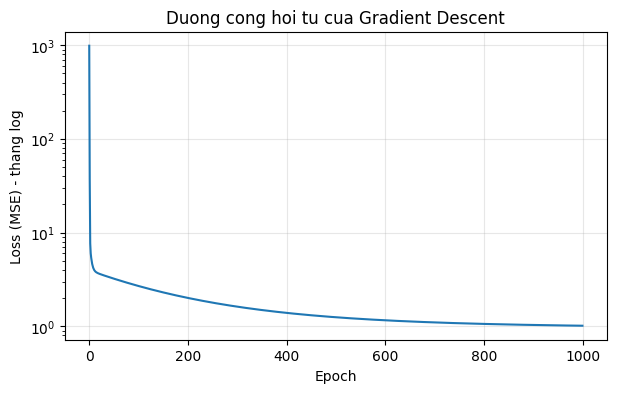

In [4]:
plt.plot(model.history)
plt.yscale("log")
plt.xlabel("Epoch"); plt.ylabel("Loss (MSE) - thang log")
plt.title("Duong cong hoi tu cua Gradient Descent")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Minh họa learning rate decay

$\eta_t = \eta_0 / (1 + \text{decay}\cdot t)$ — decay càng lớn, η tụt càng nhanh. Lúc đầu η lớn để đi nhanh, về sau η nhỏ để "đáp" êm vào đáy (không dao động).

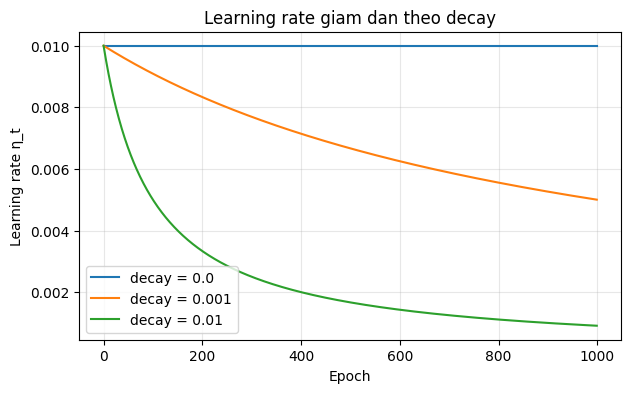

In [5]:
epochs = np.arange(1000)
for d in [0.0, 0.001, 0.01]:
    lr_t = 0.01 / (1.0 + d * epochs)
    plt.plot(epochs, lr_t, label=f"decay = {d}")
plt.xlabel("Epoch"); plt.ylabel("Learning rate η_t")
plt.title("Learning rate giam dan theo decay")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 5. 🔑 Vì sao phải chuẩn hóa trục (feature scaling)?

η là **một** bước áp cho **mọi** hướng. Nếu các trục lệch thang ($x_1 \in [0,1]$ vs $x_2 \in [0,1000]$) → mặt loss méo thành thung lũng hẹp → cùng một η: đủ lớn cho trục thoải thì **vọt** trục dốc (phân kỳ), đủ nhỏ cho trục dốc thì **bò** trục thoải (chậm).

**Chuẩn hóa** (standardize: mean 0, std 1) → mặt loss tròn lại → gradient chỉ thẳng vào tâm → **một η chạy tốt mọi hướng**. So sánh dưới đây cho thấy rõ.

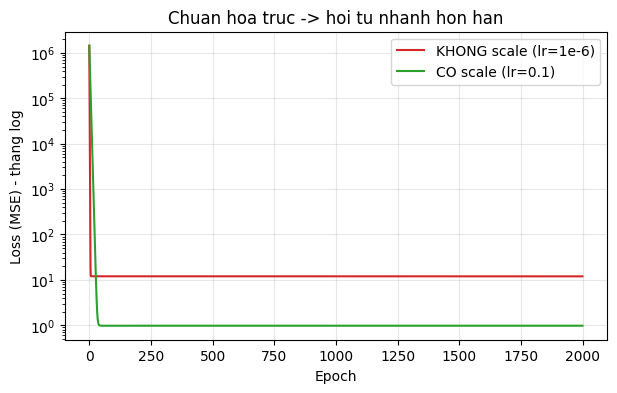

Loss cuoi - KHONG scale: 11.9651
Loss cuoi - CO scale   : 0.9786


In [6]:
# Du lieu co 2 truc LECH THANG manh
rng2 = np.random.default_rng(0)
n = 200
x1 = rng2.uniform(0, 1, n)        # truc nho
x2 = rng2.uniform(0, 1000, n)     # truc lon gap ~1000 lan
X_raw = np.column_stack([x1, x2])
y2 = 3 * x1 + 2 * x2 + 5 + rng2.normal(0, 1, n)

# (a) KHONG scale -> phai dung lr rat nho keo phan ky -> hoi tu CHAM
m_raw = LinearRegression(lr=1e-6, n_iters=2000, decay=0.0).fit(X_raw, y2, verbose=False)

# (b) CO scale (standardize) -> dung lr lon -> hoi tu NHANH
mu, sigma = X_raw.mean(axis=0), X_raw.std(axis=0)
X_scaled = (X_raw - mu) / sigma
m_scaled = LinearRegression(lr=0.1, n_iters=2000, decay=0.0).fit(X_scaled, y2, verbose=False)

plt.plot(m_raw.history, label="KHONG scale (lr=1e-6)", color="tab:red")
plt.plot(m_scaled.history, label="CO scale (lr=0.1)", color="tab:green")
plt.yscale("log")
plt.xlabel("Epoch"); plt.ylabel("Loss (MSE) - thang log")
plt.title("Chuan hoa truc -> hoi tu nhanh hon han")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print("Loss cuoi - KHONG scale:", round(m_raw.history[-1], 4))
print("Loss cuoi - CO scale   :", round(m_scaled.history[-1], 4))

> 💡 Khi dùng model đã train trên dữ liệu **scaled**, nhớ scale luôn dữ liệu mới bằng **cùng** `mu`, `sigma` (không tính lại từ dữ liệu test — tránh rò rỉ dữ liệu / data leakage).

## 6. Đối chiếu với Normal Equation (nghiệm dạng đóng)

$\hat{\beta} = (X_b^\top X_b)^{-1} X_b^\top y$ — giải thẳng 1 bước (thêm cột 1 cho bias). So với nghiệm Gradient Descent ở mục 2 phải khớp nhau.

In [7]:
X_b = np.c_[np.ones((X.shape[0], 1)), X]        # them cot bias x0 = 1
beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y   # Normal Equation

print("Normal Equation -> b =", round(beta[0], 3), ", w =", np.round(beta[1:], 3))
print("Gradient Descent -> b =", round(model.b, 3), ", w =", np.round(model.w, 3))

# Danh gia nhanh: R^2 va RMSE tren chinh tap nay
y_hat = model.predict(X)
rss = np.sum((y - y_hat) ** 2)
tss = np.sum((y - y.mean()) ** 2)
r2 = 1 - rss / tss
rmse = np.sqrt(np.mean((y - y_hat) ** 2))
print(f"\nR^2  = {r2:.4f}   (cang gan 1 cang tot)")
print(f"RMSE = {rmse:.4f}  (cung don vi voi y)")

Normal Equation -> b = 5.026 , w = [3.037 1.949]
Gradient Descent -> b = 4.411 , w = [3.088 2.004]

R^2  = 0.9908   (cang gan 1 cang tot)
RMSE = 1.0070  (cung don vi voi y)


## ✅ Tóm tắt

| Thành phần | Hàm trong class | Ý chính |
|---|---|---|
| Dự đoán | `predict` | $\hat{y} = Xw + b$ |
| Mất mát | `compute_loss` | MSE — trung bình bình phương sai số |
| **Đạo hàm** | `compute_gradients` | $\frac{2}{n}X^\top(\hat{y}-y)$ và $\frac{2}{n}\sum(\hat{y}-y)$ |
| Decay | `_current_lr` | $\eta_t = \eta_0/(1+\text{decay}\cdot t)$ |
| **Vòng lặp** | `fit` | dự đoán → gradient → cập nhật ngược hướng |

**3 điều rút ra:**
1. Gradient descent "đi mò" kéo loss xuống đáy — hội tụ vì MSE là hàm **lồi** (1 cực tiểu).
2. **Decay** giúp đáp êm vào đáy, dập dao động cuối train.
3. **Chuẩn hóa trục** là điều kiện để η hiệu quả — phần *bạn* kiểm soát (xử lý dữ liệu), không phải cái máy.

→ Lý thuyết: `linear-regression.md` · `gradient-descent.md` · `metric-hoi-quy.md` · `chuan-hoa-du-lieu.md`.